In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_data))
print("Testing samples:", len(test_data))

100%|██████████| 9.91M/9.91M [00:00<00:00, 67.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.66MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.6MB/s]

Training samples: 60000
Testing samples: 10000


In [3]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1000, shuffle=False)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 938
Test batches: 10


Image shape: torch.Size([1, 28, 28])
Label: 5


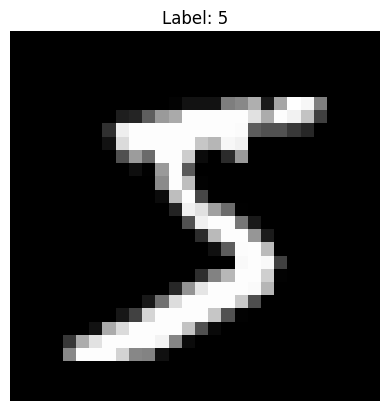

In [4]:
image, label = train_data[0]

print("Image shape:", image.shape)
print("Label:", label)

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

In [5]:
class MNISTModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.pool = nn.MaxPool2d(2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout(x)

        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [6]:
model = MNISTModel().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.7)

print(model)

MNISTModel(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.25, inplace=False)
)


In [7]:
def train(model, train_loader, optimizer, criterion, epoch):
    model.train()

    total_loss = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if batch_idx % 100 == 0:
            print(f"Epoch {epoch}, Batch {batch_idx}, Loss: {loss.item():.4f}")

    average_loss = total_loss / len(train_loader)
    return average_loss

In [8]:
def test(model, test_loader, criterion):
    model.eval()

    total_loss = 0
    correct = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()

    average_loss = total_loss / len(test_loader)
    accuracy = 100 * correct / len(test_loader.dataset)

    print(f"Test Loss: {average_loss:.4f}, Test Accuracy: {accuracy:.2f}%")

    return average_loss, accuracy

In [9]:
epochs = 5

train_losses = []
test_losses = []
test_accuracies = []

for epoch in range(1, epochs + 1):
    print("Starting epoch", epoch)

    train_loss = train(model, train_loader, optimizer, criterion, epoch)
    test_loss, test_accuracy = test(model, test_loader, criterion)

    scheduler.step()

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    print(f"Epoch {epoch} finished")
    print(f"Average training loss: {train_loss:.4f}")
    print(f"Test accuracy: {test_accuracy:.2f}%")
    print()

Starting epoch 1
Epoch 1, Batch 0, Loss: 2.2953
Epoch 1, Batch 100, Loss: 0.2416
Epoch 1, Batch 200, Loss: 0.0297
Epoch 1, Batch 300, Loss: 0.1276
Epoch 1, Batch 400, Loss: 0.0524
Epoch 1, Batch 500, Loss: 0.1485
Epoch 1, Batch 600, Loss: 0.1230
Epoch 1, Batch 700, Loss: 0.0264
Epoch 1, Batch 800, Loss: 0.0552
Epoch 1, Batch 900, Loss: 0.1570
Test Loss: 0.0508, Test Accuracy: 98.40%
Epoch 1 finished
Average training loss: 0.1439
Test accuracy: 98.40%

Starting epoch 2
Epoch 2, Batch 0, Loss: 0.0650
Epoch 2, Batch 100, Loss: 0.0254
Epoch 2, Batch 200, Loss: 0.0363
Epoch 2, Batch 300, Loss: 0.0562
Epoch 2, Batch 400, Loss: 0.0070
Epoch 2, Batch 500, Loss: 0.0263
Epoch 2, Batch 600, Loss: 0.0067
Epoch 2, Batch 700, Loss: 0.0404
Epoch 2, Batch 800, Loss: 0.0544
Epoch 2, Batch 900, Loss: 0.0166
Test Loss: 0.0319, Test Accuracy: 99.03%
Epoch 2 finished
Average training loss: 0.0474
Test accuracy: 99.03%

Starting epoch 3
Epoch 3, Batch 0, Loss: 0.0286
Epoch 3, Batch 100, Loss: 0.0162
Epoch 3

In [10]:
torch.save(model.state_dict(), "mnist_model.pt")
print("Model saved as mnist_model.pt")

Model saved as mnist_model.pt


In [11]:
loaded_model = MNISTModel().to(device)
loaded_model.load_state_dict(torch.load("mnist_model.pt", map_location=device))
loaded_model.eval()

print("Model loaded successfully")

Model loaded successfully


Actual label: 7
Predicted label: 7


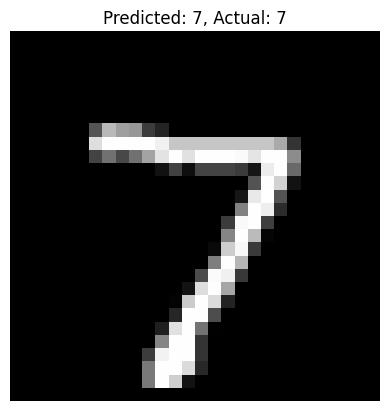

In [12]:
sample_image, sample_label = test_data[0]

with torch.no_grad():
    image = sample_image.unsqueeze(0).to(device)
    output = loaded_model(image)
    prediction = output.argmax(dim=1).item()

print("Actual label:", sample_label)
print("Predicted label:", prediction)

plt.imshow(sample_image.squeeze(), cmap="gray")
plt.title(f"Predicted: {prediction}, Actual: {sample_label}")
plt.axis("off")
plt.savefig("sample_prediction.png")
plt.show()

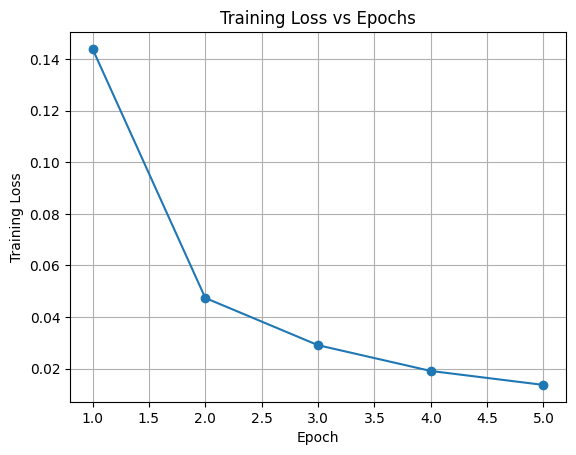

In [13]:
plt.plot(range(1, epochs + 1), train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epochs")
plt.grid(True)
plt.savefig("training_loss.png")
plt.show()

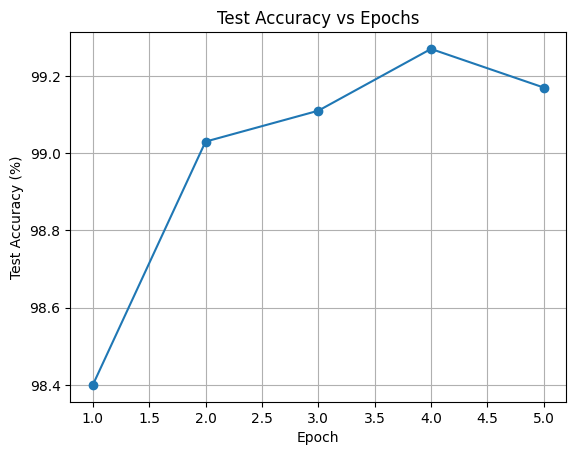

In [14]:
plt.plot(range(1, epochs + 1), test_accuracies, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("Test Accuracy vs Epochs")
plt.grid(True)
plt.savefig("test_accuracy.png")
plt.show()

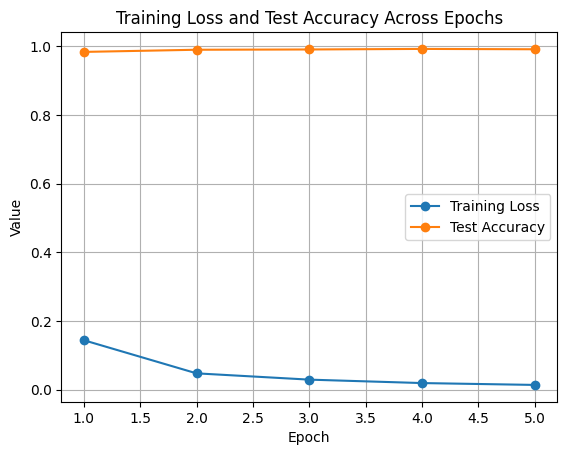

In [15]:
plt.plot(range(1, epochs + 1), train_losses, marker="o", label="Training Loss")
plt.plot(range(1, epochs + 1), [acc / 100 for acc in test_accuracies], marker="o", label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Training Loss and Test Accuracy Across Epochs")
plt.legend()
plt.grid(True)
plt.savefig("loss_accuracy_curve.png")
plt.show()

Task 1: Training Loop

The training loop follows this pattern: zero gradients, forward pass, compute loss, backward pass, and update weights.

I used CrossEntropyLoss because MNIST is a multi-class classification problem with 10 digit classes. I used Adam optimizer because it usually works well without too much manual tuning. I also used StepLR scheduler to reduce the learning rate after each epoch.

Task 2: Evaluation

For evaluation, I used model.eval() so that layers like dropout behave correctly during testing. I also used torch.no_grad() because gradients are not needed while evaluating the model and the test function calculates average test loss and accuracy on the unseen test set.

Task 3: Save and Load

I saved the model using state_dict instead of saving the full model. Saving state_dict stores only the learned weights and biases, which is more flexible. To load it again, I recreated the model architecture and loaded the saved state_dict into it.

I managed to complete MNIST digit classification for training, testing, saving, loading, and inference in this task.

Throughout the number of epochs, it could be observed that the training loss had been decreasing, showing that learning was going on. The highest accuracy obtained in testing was 99.27%, achieved in epoch four compared to 98.40% in epoch one. However, epoch five showed a slightly reduced accuracy to 99.17%, but it's an insignificant drop and therefore doesn't indicate overfitting.

The minimum criterion of 98% was met by the model. There were many ways through which I would enhance my model, including changing the learning rate, adding/dropping dropout, training with early stopping, and comparing Adam, SGD, and Adadelta.